<a href="https://colab.research.google.com/github/spentapa3-lgtm/deeplearning-/blob/main/OR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

OR GATE SINGLE PERCEPTRON - HARD-CODED WEIGHTS
 Weights: W=1.0, W=1.0
 Bias: b=-0.5
 Equation: 1.0x + 1.0x + -0.5 > 0

PREDICTIONS
[0, 0] → Linear: -0.5 → Pred: 0 | Actual:0
[0, 1] → Linear:  0.5 → Pred: 1 | Actual:1
[1, 0] → Linear:  0.5 → Pred: 1 | Actual:1
[1, 1] → Linear:  1.5 → Pred: 1 | Actual:1


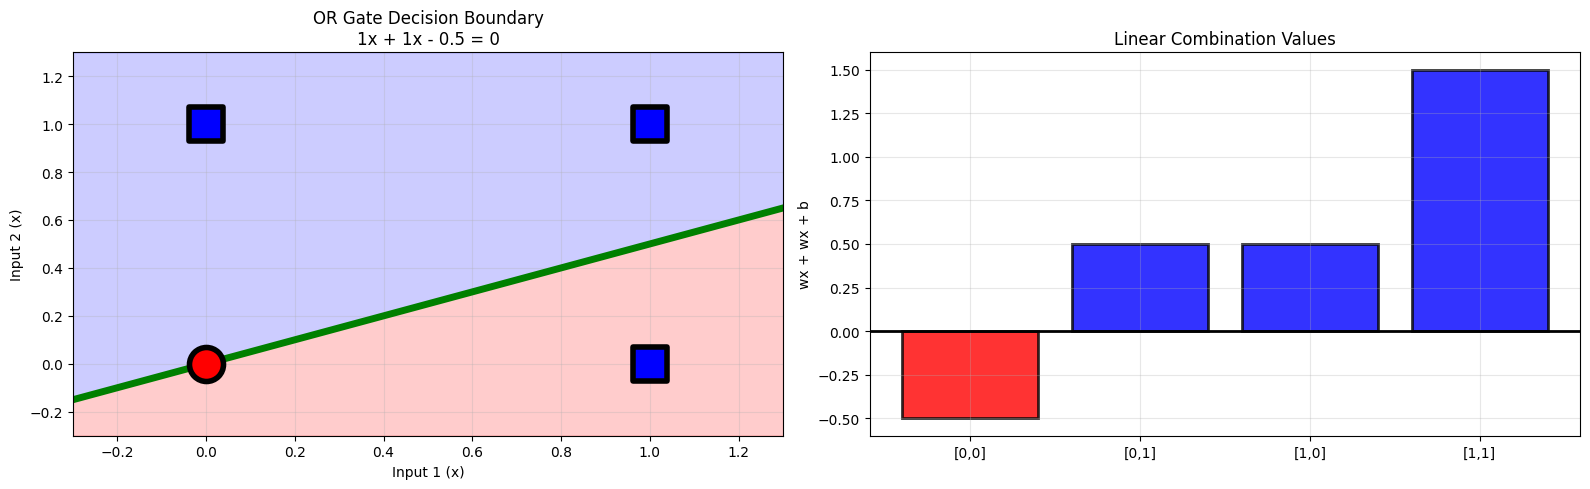


VERIFICATION RESULTS:
 . Decision boundary: x = (-1x + 0.5)/1
Linear values for each input:
 [0,0]: 1*0 + 1*0 - 0.5 = -0.5
 Class 0 (<=0)
 [0,1]: 1*0 + 1*1 - 0.5 = 0.5
 Class 1 (>0)
 [1,0]: 1*1 + 1*0 - 0.5 = 0.5
 Class 1 (>0)
 [1,1]: 1*1 + 1*1 - 0.5 = 1.5
 Class 1 (>0)

Point positions relative to boundary: 
[0,0]: -0.500 Below (Class 0) 
[0,1]: 0.500 Above (Class 1) 
[1,0]: 0.500 Above (Class 1) 
[1,1]: 1.500 Above (Class 1) 


In [1]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [1]])

print("OR GATE SINGLE PERCEPTRON - HARD-CODED WEIGHTS")
print("="*60)

weights = np.array([[1.0], [1.0]])
bias = np.array([[-0.5]])

print(f" Weights: W={weights[0,0]:.1f}, W={weights[1,0]:.1f}")
print(f" Bias: b={bias[0,0]:.1f}")
print(f" Equation: {weights[0,0]:.1f}x + {weights[1,0]:.1f}x + {bias[0,0]:.1f} > 0")

def step_function(x):
    return 1 if x > 0 else 0

def perceptron_predict(X, weights, bias):
    linear = np.dot(X, weights) + bias
    predictions = np.zeros((4, 1))
    for i in range(len(linear)):
        predictions[i, 0] = step_function(linear[i, 0])
    return predictions

print("\nPREDICTIONS")
linear_values = np.dot(X, weights) + bias
predictions = perceptron_predict(X, weights, bias)

for i in range(len(X)):
    linear_val = linear_values[i, 0]
    pred = predictions[i][0]
    actual = y[i][0]
    print(f"[{X[i,0]:.0f}, {X[i,1]:.0f}] → Linear:{linear_val:5.1f} → Pred: {int(pred)} | Actual:{int(actual)}")

plt.figure(figsize=(16, 5))
plt.subplot(1, 2, 1)
plt.scatter(X[y.flatten()==0, 0], X[y.flatten()==0, 1], s=600, c='red', marker='o', edgecolors='black', linewidth=4, label='Class 0', zorder=3)
plt.scatter(X[y.flatten()==1, 0], X[y.flatten()==1, 1], s=600, c='blue', marker='s', edgecolors='black', linewidth=4, label='Class 1', zorder=4)

x1_range = np.linspace(-0.3, 1.3, 100)
w1, w2, b = 1.0, 1.0, -0.5
x2_boundary = (-w1 * x1_range * b) / w2 # Added missing operator
plt.plot(x1_range, x2_boundary, 'g-', linewidth=5, label='Decision Boundary', zorder=2)

plt.fill_between(x1_range, x2_boundary, 1.3, alpha=0.2, color='blue', label='Class 1 Region')
plt.fill_between(x1_range, -0.3, x2_boundary, alpha=0.2, color='red', label='Class 0 Region') # Changed 'O' to '0'

plt.xlim(-0.3, 1.3)
plt.ylim(-0.3, 1.3)
plt.xlabel('Input 1 (x)')
plt.ylabel('Input 2 (x)')
plt.title('OR Gate Decision Boundary\n1x + 1x - 0.5 = 0') # Corrected equation and removed '0.5 = 0' which was already in the equation
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
samples = ['[0,0]', '[0,1]', '[1,0]', '[1,1]'] # Corrected list declaration
linear_vals = linear_values.flatten()
colors = ['red', 'blue', 'blue', 'blue']

plt.bar(samples, linear_vals, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
plt.axhline(y=0, color='black', linestyle='-', linewidth=2, label='Threshold')
plt.ylabel('wx + wx + b')
plt.title('Linear Combination Values') # Added missing parenthesis
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nVERIFICATION RESULTS:")
print(f" . Decision boundary: x = (-1x + 0.5)/1")
print("Linear values for each input:")
for i in range(4):
    z = 1*X[i,0] + 1*X[i,1] - 0.5
    print(f" [{X[i,0]:.0f},{X[i,1]:.0f}]: 1*{X[i,0]:.0f} + 1*{X[i,1]:.0f} - 0.5 = {z:.1f}") # Corrected f-string
    print(f" {'Class 1 (>0)' if z > 0 else 'Class 0 (<=0)'}") # Corrected f-string and condition

print("\nPoint positions relative to boundary: ")
for i in range(len(X)):
    point_value = weights[0,0]*X[i,0] + weights[1,0]*X[i,1] + bias[0,0]
    side = "Above (Class 1)" if point_value > 0 else "Below (Class 0)" # Changed 'O' to '0'
    print(f"[{X[i,0]:.0f},{X[i,1]:.0f}]: {point_value:.3f} {side} ")